In [2]:
!pip install nltk

     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.5 kB ? eta -:--:--
     ------------------ ------------------- 20.5/41.5 kB 320.0 kB/s eta 0:00:01
     -------------------------------------- 41.5/41.5 kB 400.4 kB/s eta 0:00:00
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   - -------------------------------------- 0.0/1.6 MB 960.0 kB/s eta 0:00:02
   --- ------------------------------------ 0.1/1.6 MB 1.3 MB/s eta 0:00:02
   ------ --------------------------------- 0.3/1.6 MB 1.8 MB/s eta 0:00:01
   ------------ --------------------------- 0.5/1.6 MB 2.7 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------  1.5/1.6 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.5 MB/s eta 0:00:00
   ----------------------------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
df = pd.read_csv('../employee.csv')
print('Missing values:\n', df.isnull().sum())
print('\nDescribe :\n', df.describe())
print('\nInfo:')
print(df.info())
print('Shape:', df.shape)

Missing values:
 Name          0
Age           1
Salary        1
Gender        0
Department    0
dtype: int64

Describe :
              Age        Salary
count   4.000000      4.000000
mean   29.500000  65000.000000
std     4.203173  12909.944487
min    25.000000  50000.000000
25%    27.250000  57500.000000
50%    29.000000  65000.000000
75%    31.250000  72500.000000
max    35.000000  80000.000000

Info:
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      str    
 1   Age         4 non-null      float64
 2   Salary      4 non-null      float64
 3   Gender      5 non-null      str    
 4   Department  5 non-null      str    
dtypes: float64(2), str(3)
memory usage: 392.0 bytes
None
Shape: (5, 5)


In [13]:
if 'Salary' in df.columns:
    df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
    print('true')

true


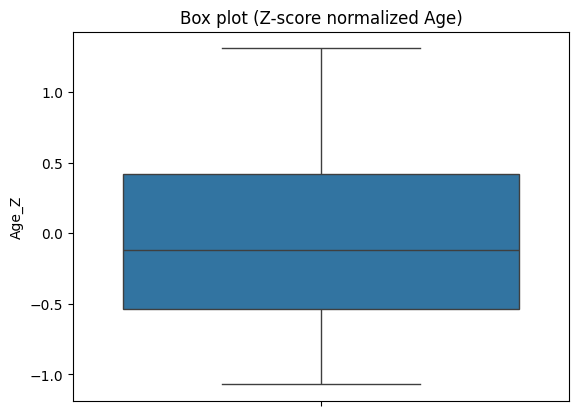

In [14]:
df['Age_Z'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()
sns.boxplot(y=df['Age_Z'])
plt.title('Box plot (Z-score normalized Age)')
plt.show()

In [15]:
cat_cols = df.select_dtypes(include=['object']).columns
df_enc = pd.get_dummies(df, columns=cat_cols, drop_first=False)
df_enc.head()

C:\Users\vedan\AppData\Local\Temp\ipykernel_23588\582515443.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


,Age,Salary,Age_Z,Name_Alice,Name_Bob,Name_Charlie,Name_David,Name_Eve,Gender_Female,Gender_Male,Department_HR,Department_IT,Department_Sales
0,25.0,50000.0,-1.070620,True,False,False,False,False,True,False,True,False,False
1,30.0,60000.0,0.118958,False,True,False,False,False,False,True,False,True,False
2,NaN,70000.0,NaN,False,False,True,False,False,False,True,False,True,False
3,35.0,80000.0,1.308535,False,False,False,True,False,False,True,False,False,True
4,28.0,NaN,-0.356873,False,False,False,False,True,True,False,True,False,False
